[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EQuS/jaxquantum/blob/main/docs/documentation/tutorials/devices.ipynb)

In [1]:
# !pip install git+https://github.com/EQuS/jaxquantum.git  # Uncomment when running in Colab.

# Devices & Systems

*This is an executable IPython Notebook tutorial.*

jaxquantum ships with ready-to-use superconducting circuit device models — Transmon, Fluxonium, Resonator, and more. Each device:

- stores physical parameters and a Hilbert-space dimension,
- diagonalizes its Hamiltonian on construction,
- exposes eigenenergies and eigenstates via `.eig_systems`,
- can plot its wavefunctions via `.plot_wavefunctions()`.

Because device creation is a pure JAX computation, it composes naturally with `jax.jit` and `jax.vmap` for fast parameter sweeps, and with `jax.grad` for gradient-based fitting to experimental data.

This tutorial covers:

1. **Transmon spectroscopy** — create a device, read the eigenspectrum, visualize wavefunctions.
2. **Flux sweep with `vmap`** — sweep 200 flux values in a single compiled call.
3. **Gradient-based parameter fitting** — use `jax.grad` + `optax` to recover Ec and Ej from synthetic spectroscopy data.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import jaxquantum as jqt
import jaxquantum.devices as jqtd

import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

## 1. Transmon Spectroscopy

The Transmon Hamiltonian is
$$H = 4E_C(\hat{n} - n_g)^2 - E_J\cos(\hat{\phi}),$$
where $E_C$ is the charging energy and $E_J$ is the Josephson energy. The ratio $E_J/E_C \gg 1$ suppresses charge noise.

We use the Cooper-pair charge basis (default) with `hamiltonian=full` to capture the exact cosine potential.

In [4]:
# Create a Transmon in the charge basis
# N=5 keeps the lowest 5 dressed levels; N_pre_diag=41 gives the charge-basis truncation
transmon = jqtd.Transmon.create(
    N=5,
    params={"Ec": 0.3, "Ej": 15.0},  # GHz
    N_pre_diag=41,
    basis=jqtd.BasisTypes.charge,
    hamiltonian=jqtd.HamiltonianTypes.full,
)

Es = transmon.eig_systems["vals"]  # sorted eigenvalues

f_01 = Es[1] - Es[0]          # qubit frequency
anharmonicity = (Es[2] - Es[1]) - (Es[1] - Es[0])  # alpha = f_12 - f_01

print(f"f_01          = {f_01:.4f} GHz")
print(f"anharmonicity = {anharmonicity:.4f} GHz")
print(f"Ej/Ec         = {15.0/0.3:.1f}   (charge-noise protected regime: Ej/Ec >> 1)")

f_01          = 5.6826 GHz
anharmonicity = -0.3448 GHz
Ej/Ec         = 50.0   (charge-noise protected regime: Ej/Ec >> 1)


<Axes: title={'center': '$|\\psi_n(\\Phi)|^2$'}, xlabel='$\\varphi/2\\pi$', ylabel='Energy [GHz]'>

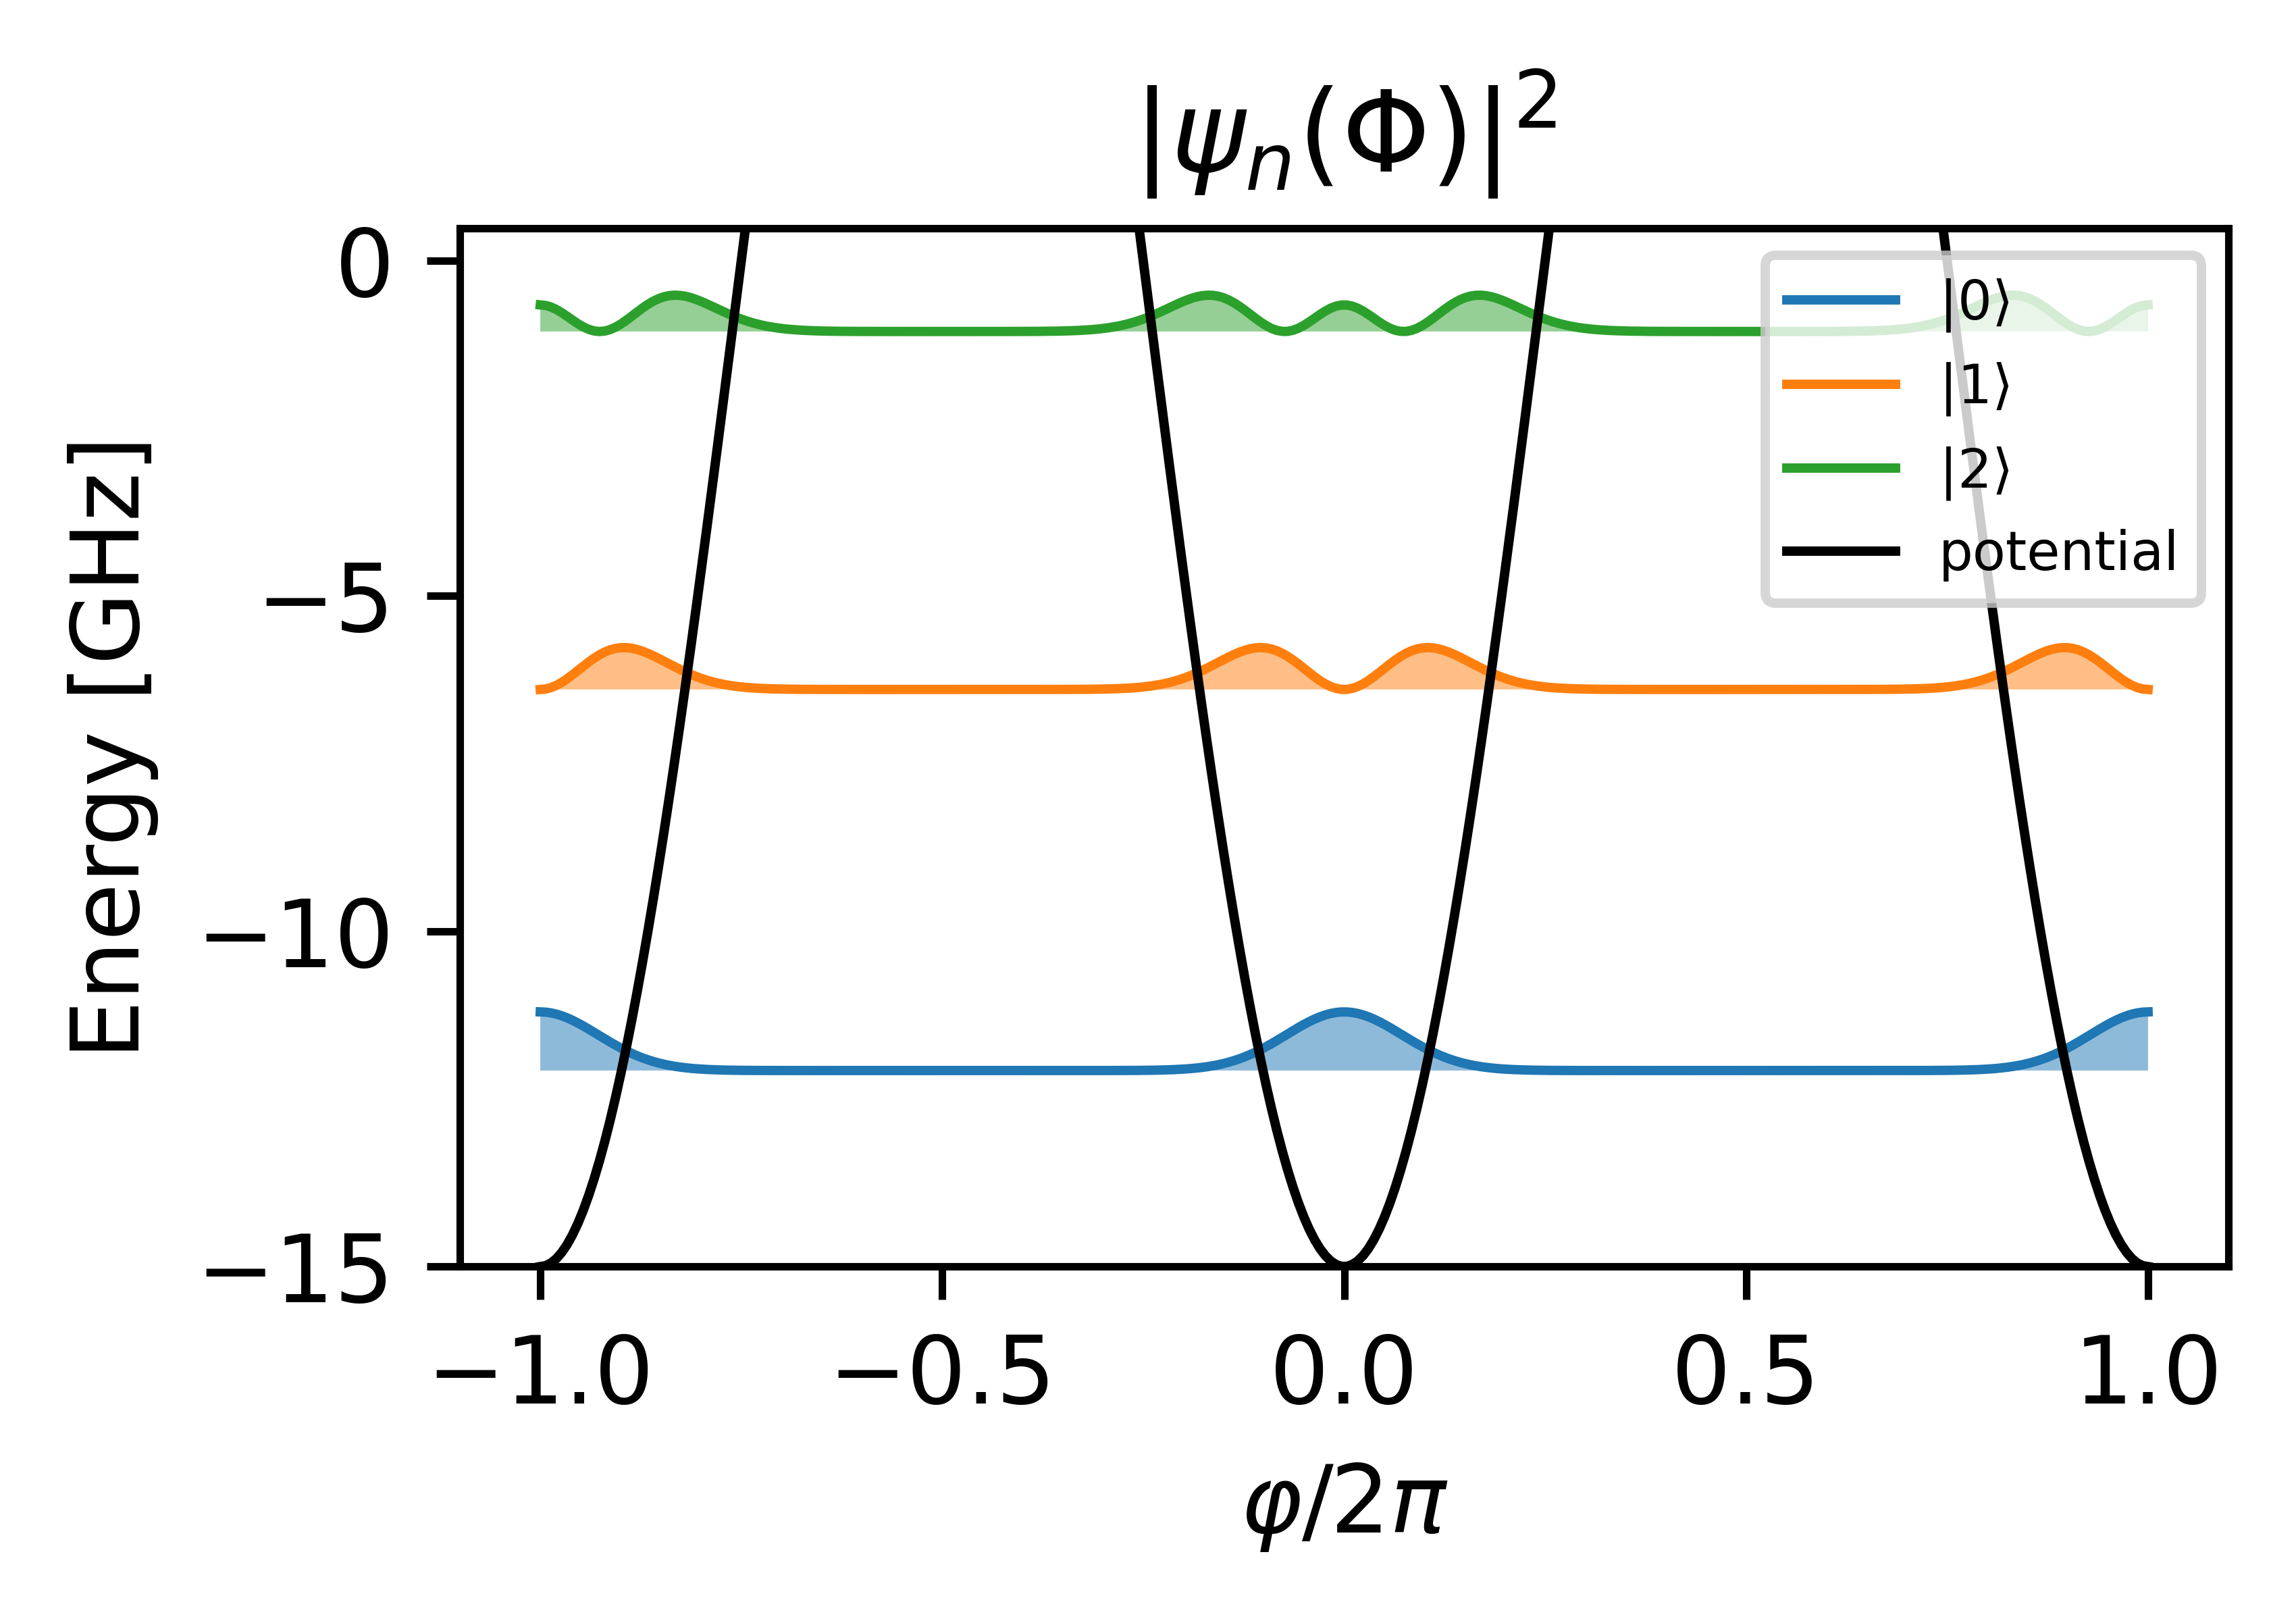

In [5]:
# Visualise the first few wavefunctions on top of the cosine potential
phi_vals = jnp.linspace(-1.0, 1.0, 300)
transmon.plot_wavefunctions(phi_vals, max_n=3)

## 2. Flux Sweep with `vmap`

A TunableTransmon (SQUID loop) has an external flux degree of freedom `phi_ext` that shifts the effective $E_J$:
$$E_J(\Phi_{\rm ext}) = 2E_{J0}\left|\cos\!\left(\pi\frac{\Phi_{\rm ext}}{\Phi_0}\right)\right|.$$

We wrap device creation in a `jit`-compiled function and use `jax.vmap` to sweep 200 flux points — a single compiled call that runs in ~1 s on CPU and ~50 ms on GPU.

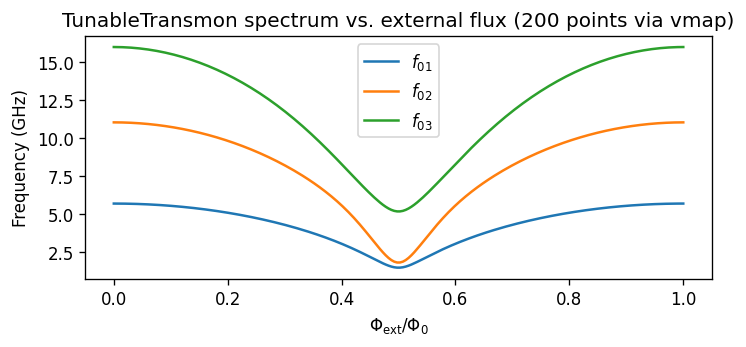

In [6]:
def get_transmon_freqs(phi_ext):
    """Return the lowest 4 energy levels (relative to ground) for a given external flux."""
    # TunableTransmon uses Ej1, Ej2 (two SQUID junctions) and phi_ext
    t = jqtd.TunableTransmon.create(
        N=4,
        params={"Ec": 0.3, "Ej1": 8.0, "Ej2": 7.0, "phi_ext": phi_ext},
        N_pre_diag=41,
        basis=jqtd.BasisTypes.charge,
        hamiltonian=jqtd.HamiltonianTypes.full,
    )
    Es = t.eig_systems["vals"]
    return Es - Es[0]  # energies relative to ground state

# vmap over 200 flux values — one compiled call
phi_ext_vals = jnp.linspace(0.0, 1.0, 200)
all_freqs = jax.vmap(get_transmon_freqs)(phi_ext_vals)  # shape (200, 4)

fig, ax = plt.subplots(figsize=(6, 3), dpi=120)
for level in range(1, 4):
    ax.plot(phi_ext_vals, all_freqs[:, level], label=f"$f_{{0{level}}}$")
ax.set_xlabel(r"$\Phi_\mathrm{ext} / \Phi_0$")
ax.set_ylabel("Frequency (GHz)")
ax.set_title("TunableTransmon spectrum vs. external flux (200 points via vmap)")
ax.legend()
fig.tight_layout()

The sweet spot at $\Phi_{\rm ext}/\Phi_0 = 0$ is where $f_{01}$ is maximum and first-order flux sensitivity vanishes, minimising dephasing from flux noise.

## 3. Gradient-Based Parameter Fitting

In a real experiment we measure transition frequencies and want to extract $E_C$ and $E_J$. Because jaxquantum runs on JAX, `jax.grad` differentiates straight through device creation and diagonalization — no finite differences needed.

We generate synthetic "experimental" data with known parameters, then recover them by gradient descent.

In [7]:
# --- Generate synthetic spectroscopy data ---
# A single f_01 measurement under-constrains two parameters (Ec, Ej),
# so we target both f_01 AND the anharmonicity α = f_12 - f_01.
TRUE_EC = 0.28
TRUE_EJ = 14.0

def transmon_spectrum(Ec, Ej):
    """Return (f_01, anharmonicity) for given Ec, Ej."""
    t = jqtd.Transmon.create(
        N=3,
        params={"Ec": Ec, "Ej": Ej},
        N_pre_diag=31,
        basis=jqtd.BasisTypes.charge,
        hamiltonian=jqtd.HamiltonianTypes.full,
    )
    Es = t.eig_systems["vals"]
    f_01 = Es[1] - Es[0]
    anharmonicity = (Es[2] - Es[1]) - f_01
    return f_01, anharmonicity

target_f01, target_alpha = transmon_spectrum(TRUE_EC, TRUE_EJ)
print(f"Target f_01          = {float(target_f01):.6f} GHz")
print(f"Target anharmonicity = {float(target_alpha):.6f} GHz")

Target f_01          = 5.303737 GHz
Target anharmonicity = -0.321782 GHz


In [8]:
# --- Fit with jax.grad + optax ---
@jax.jit
def loss(log_Ec, log_Ej):
    """Work in log-space so parameters stay positive."""
    Ec = jnp.exp(log_Ec)
    Ej = jnp.exp(log_Ej)
    f_01, alpha = transmon_spectrum(Ec, Ej)
    return (f_01 - target_f01) ** 2 + (alpha - target_alpha) ** 2

# Start from a guess that's ~30% off
log_Ec = jnp.log(jnp.array(0.4))
log_Ej = jnp.log(jnp.array(11.0))

optimizer = optax.adam(learning_rate=0.05)
opt_state = optimizer.init((log_Ec, log_Ej))

losses = []
for step in range(300):
    grads = jax.grad(loss, argnums=(0, 1))(log_Ec, log_Ej)
    updates, opt_state = optimizer.update(grads, opt_state)
    log_Ec, log_Ej = optax.apply_updates((log_Ec, log_Ej), updates)
    losses.append(float(loss(log_Ec, log_Ej)))

Ec_fit = float(jnp.exp(log_Ec))
Ej_fit = float(jnp.exp(log_Ej))
print(f"True  Ec={TRUE_EC:.4f}  Ej={TRUE_EJ:.4f}")
print(f"Fit   Ec={Ec_fit:.4f}  Ej={Ej_fit:.4f}")

True  Ec=0.2800  Ej=14.0000
Fit   Ec=0.2800  Ej=14.0000


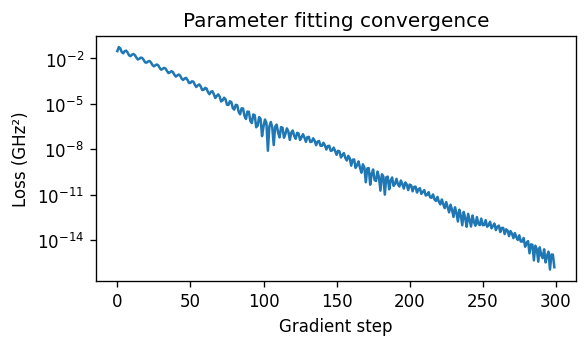

In [9]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=120)
ax.semilogy(losses)
ax.set_xlabel("Gradient step")
ax.set_ylabel("Loss (GHz²)")
ax.set_title("Parameter fitting convergence")
fig.tight_layout()

## What's Next?

- Use device operators inside a circuit: see the [Circuits tutorial](circuits.ipynb).
- Build bosonic qubit encodings on top of an oscillator mode: see [Bosonic Codes](bosonic_codes.ipynb).
- Use sparse operators to scale up to larger Hilbert spaces: see [Sparse Backends](sparse_backends.ipynb).